# Step 1:- import all libraries and load our data set

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OneHotEncoder, StandardScaler)
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

In [2]:
df = pd.read_csv(r"C:\Users\hp pc\ALL ABOUT DATA DATA SCIENCE\Customer_Churn_Project\Data\Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape # There is 7043 rows and 21 columns

(7043, 21)

# Step 2 :- Understand our data 

In [4]:
df.info() # here we get info of our data and analyze that ['TotalCharges'] column has incorrect dtype.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()# it gives us the info of maximum, minimum, std, count etc

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce') # errors = coerce matal jo dtype numeric mai nahi ho sakte unko ignore 
# here we change the dtype of ['TotalCharges'] column.

In [7]:
df.duplicated().sum()

np.int64(0)

# Step 3: - data Cleaning

In [8]:
df.isnull().sum() # here we understand that ['TotalCharges'] column has 11 null values

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
# here we fill that null values with median for better analysis and for better prediction
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [10]:
df.isnull().sum() 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Step 4:- EDA

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# 1. Univariate analysis

## 1. Churn Distribution

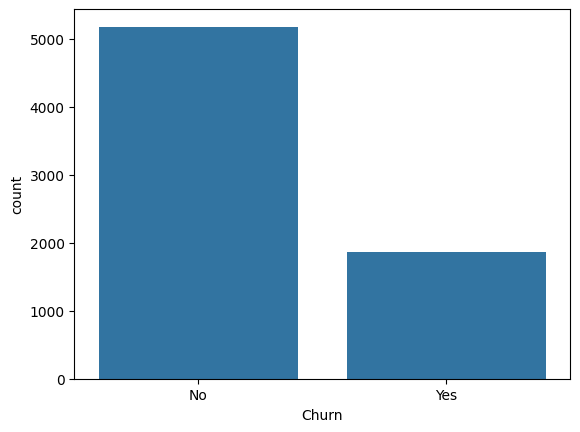

In [12]:
sns.countplot(x= 'Churn', data = df)
plt.show()

here i analyze that there is churn member are less

# 2. gender Distribution

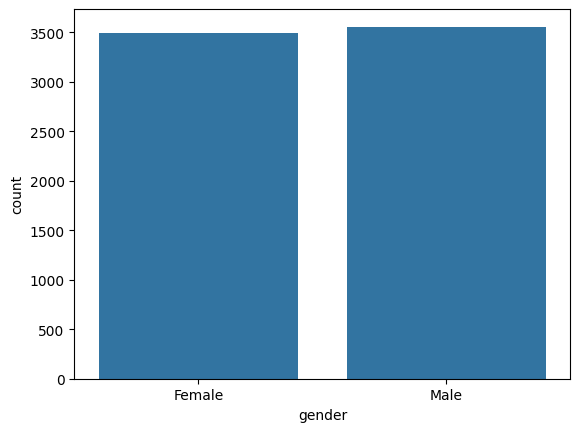

In [13]:
sns.countplot(x= 'gender', data = df)
plt.show()

here i analyze that there is female customer are less

## 3. InternetServices Distribution

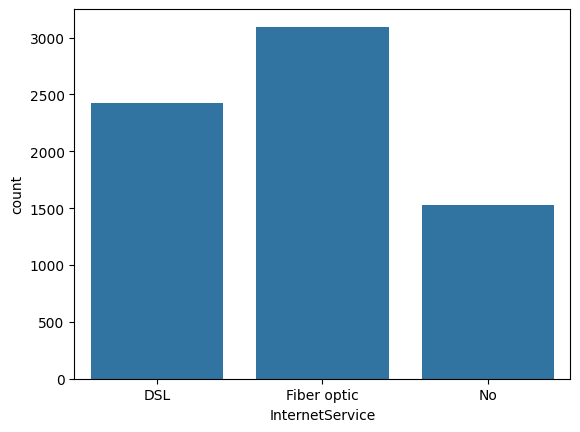

In [14]:
sns.countplot(x= 'InternetService', data = df)
plt.show()


here i analyze that there is fiber optic customer are more

## 4. monthly charges distribution

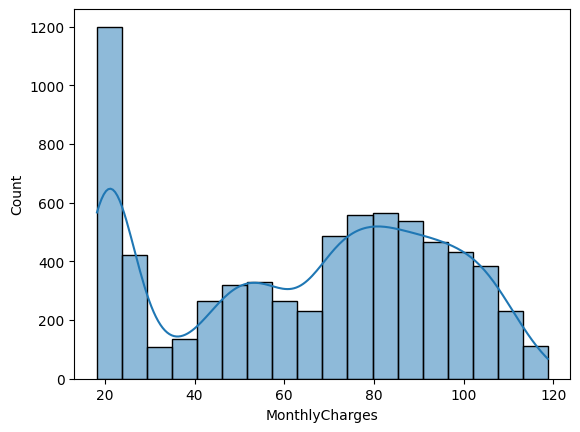

In [15]:
sns.histplot(df['MonthlyCharges'],kde=True)
plt.show()

Most customers  are in the range of ₹20–30 to ₹70–100 and more customer is in the  1st range

## 5. tenure distribution

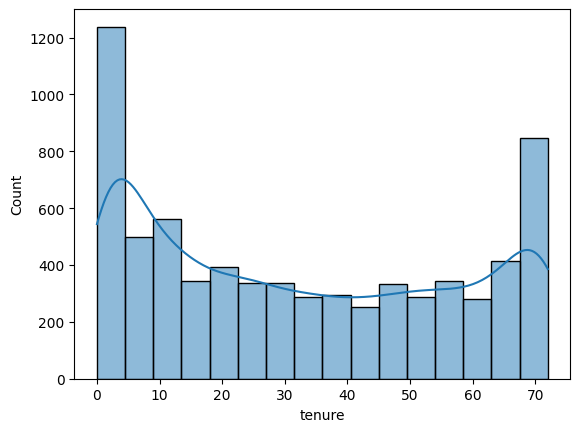

In [16]:
sns.histplot(df['tenure'],kde=True)
plt.show()


here we analyze that maximum customers stay only 5 month with the company.

## 6. Contract distribution

In [17]:
piechart = df['Contract'].value_counts()

([<matplotlib.patches.Wedge at 0x1b3b5917d00>,
 [Text(-0.17273218154189313, 1.0863533465036956, 'Month-to-month'),
  Text(-0.5267525388494891, -0.9656768418138738, 'Two year'),
  Text(0.8709807870758489, -0.6718574763629076, 'One year')])

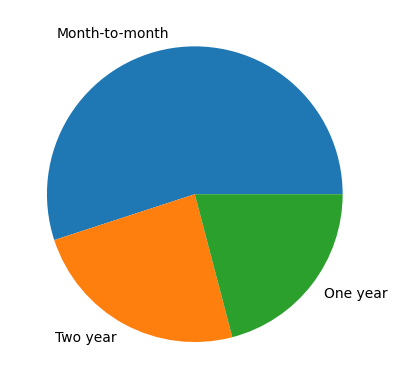

In [18]:
plt.pie(df['Contract'].value_counts(), labels = piechart.index)

here i analyze that there is month-to-month costomer is more  

# 2. Bivariate analysis

## 1. Gender vs Churn

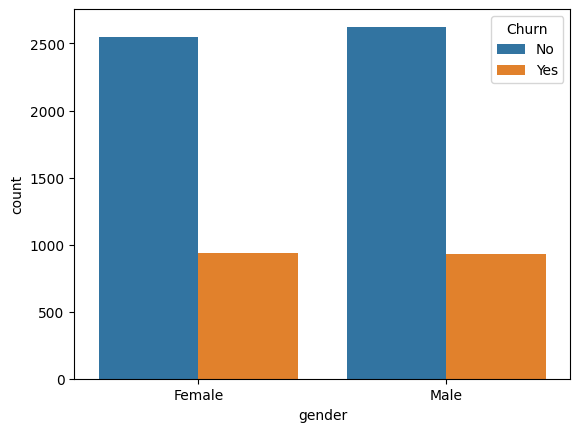

In [19]:
# Gender vs Churn
sns.countplot(x='gender',hue='Churn',data=df)
plt.show()


here i anylize that 
churn(yes) = females = males

no churned = male^ , female is less than male

## 2. Contract VS Churn

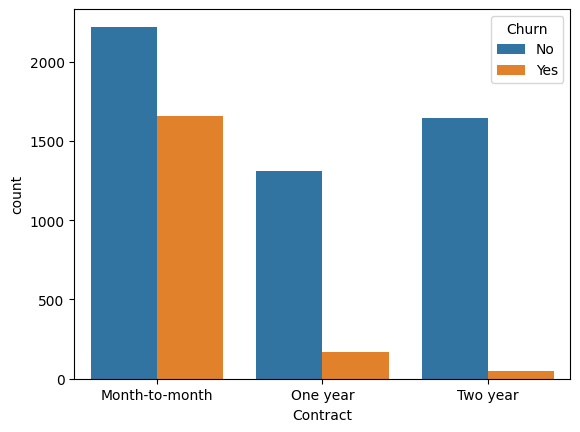

In [20]:
sns.countplot(x='Contract',hue='Churn',data=df)
plt.show()

here i anylize that monthly contracted members are more churned
conclusion:- means short term based contract is more curned and
long term based contract is less churned  

## 3. MonthlyCharges VS Churn

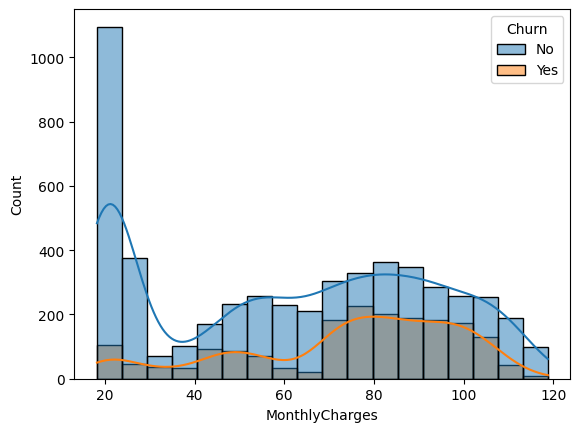

In [21]:
sns.histplot(data=df,x='MonthlyCharges',hue='Churn',kde=True)
plt.show()

so Here we have analyzed that as monthlycharges are increasing then the customer is being churned  

## 4. Tanure Analysis :- Number of months the customer has stayed with the company
## Customers with low tenure usually churn more.

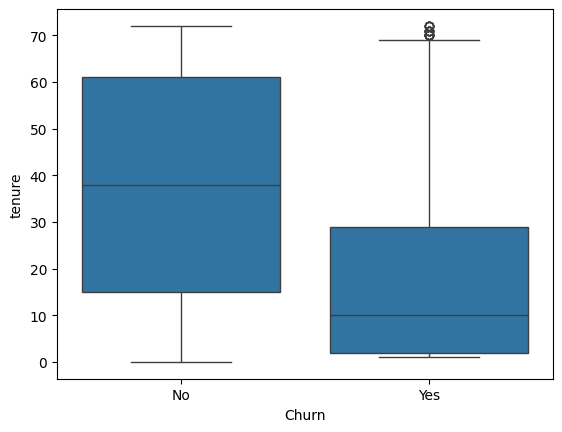

In [22]:
sns.boxplot(x='Churn', y='tenure',data=df)
plt.show()

In [23]:
print(f"Average Tenure: {df['tenure'].mean():.1f} months")

Average Tenure: 32.4 months


In [24]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

here we analyzed that Customers with low tenure usually churn more, and the 
average tenure of not churned customers is 37.569965 months and 
average tenure of churened customer is approx 17.979133 months  
and there are more outliers in yes categories 

## 5. InternetService VS Churn

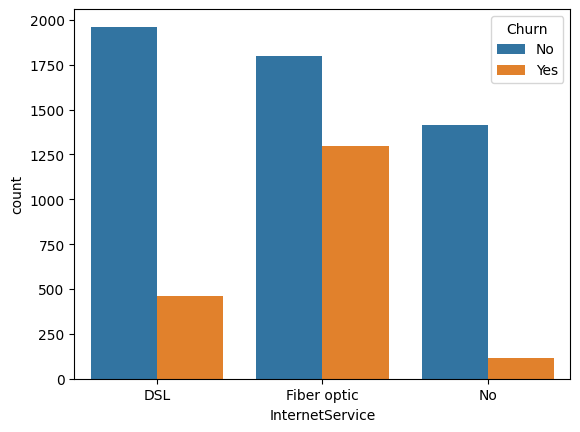

In [25]:
sns.countplot(x='InternetService',hue='Churn',data=df)
plt.show()

so here we anylyzed that fiber optics customer is more churned 

## 6. SeniorCitizen VS Churn

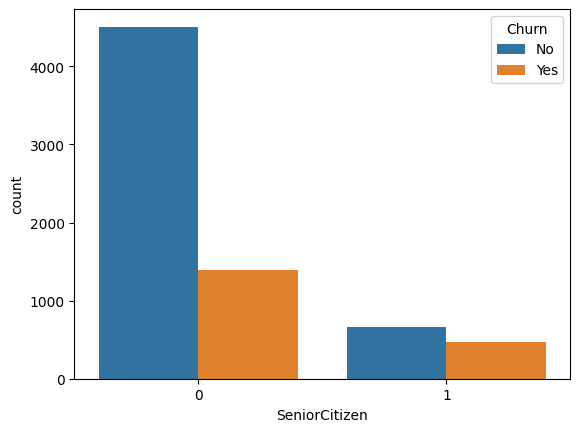

In [26]:
sns.countplot(x='SeniorCitizen',hue='Churn',data=df)
plt.show()


0 - yes 
1 - no,

seniorcitizens is more churned

# 3. multivariate analysis 

In [27]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 1. Correlation
## correlation of all  numerical value

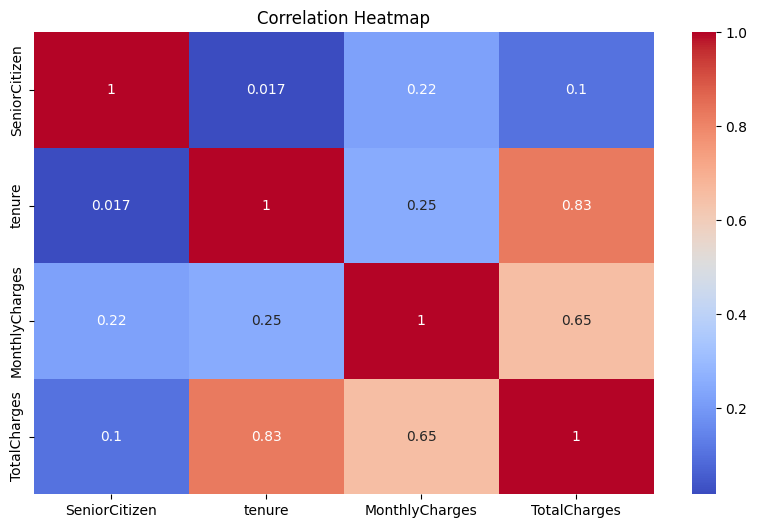

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Correlation heatmap shows the relationship between numerical features. 
The strongest positive correlation is between tenure and TotalCharges (0.83),
indicating that customers who stay longer generate higher total revenue.
MonthlyCharges and TotalCharges also show a strong positive relationship (0.65).
SeniorCitizen has very weak correlation with other variables, suggesting little linear relationship.

# 2. pairplot 

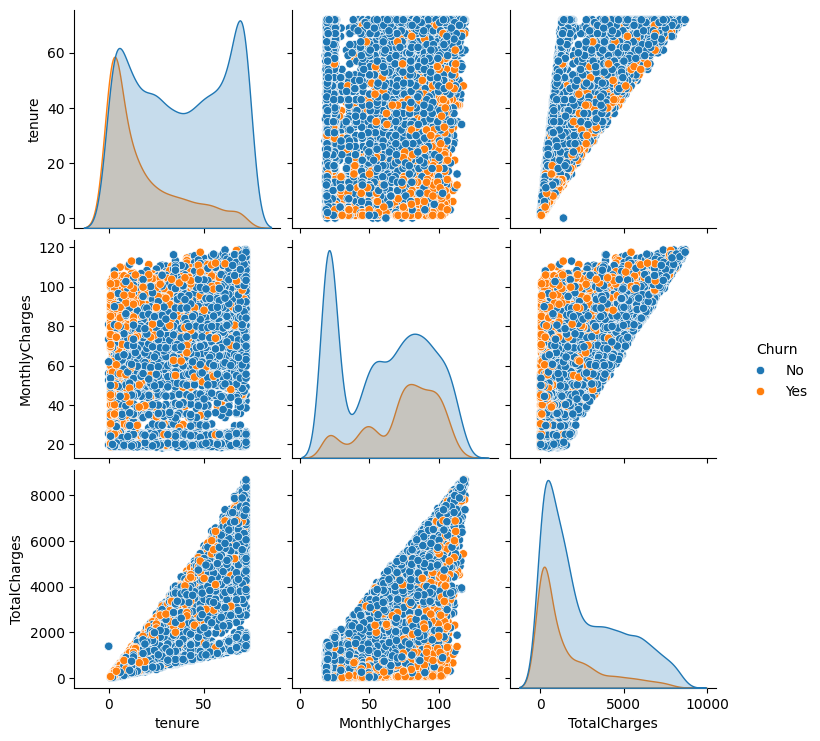

In [29]:
cols = ['tenure','MonthlyCharges','TotalCharges','Churn']
sns.pairplot(df[cols],hue='Churn')
plt.show()

 Churned customers low tenure wale hain?
 Monthly charges zyada hone par churn badh raha hai?

# 3. Internet Service + Contract + Churn

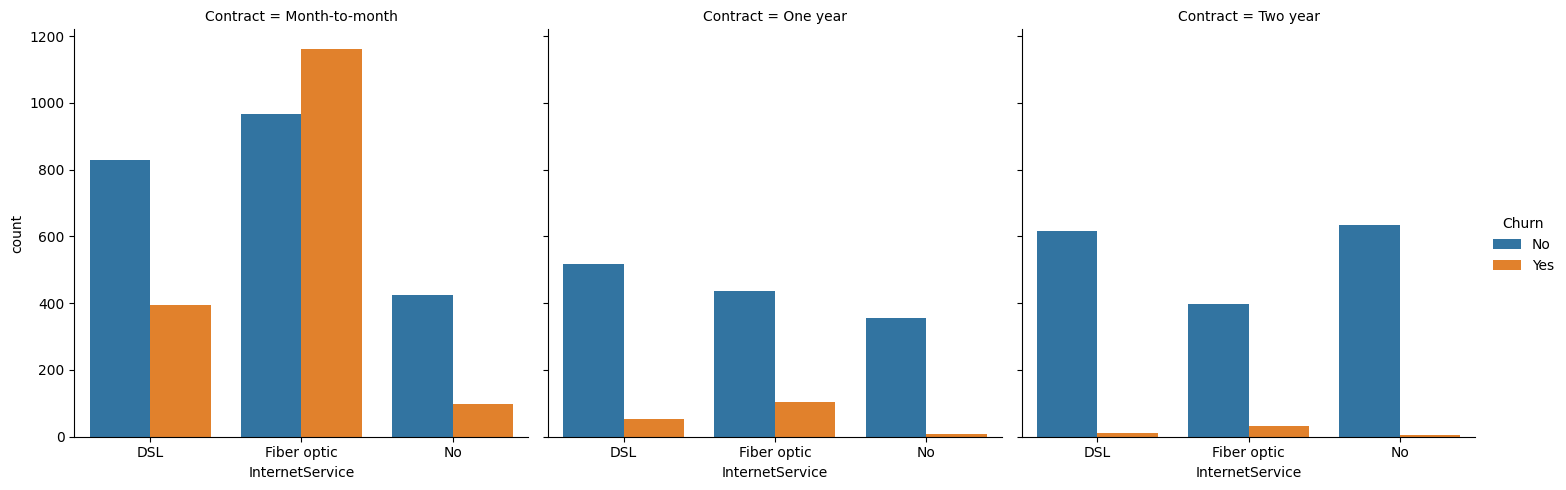

In [30]:
sns.catplot(x='InternetService',hue='Churn',col='Contract',kind='count',data=df)
plt.show()

Month-to-month customers using fiber internet have the highest churn rate.

# 4. Tenure + MonthlyCharges + Churn

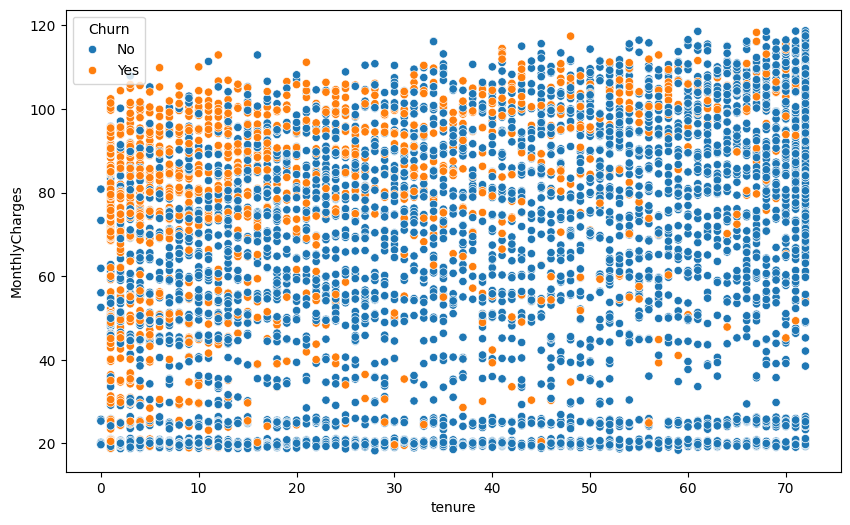

In [31]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='tenure',y='MonthlyCharges',hue='Churn',data=df)
plt.show()

Low tenure + High charges → High churn
High tenure + Low charges → Low churn

# 5. Tenure + TotalCharges + Churn

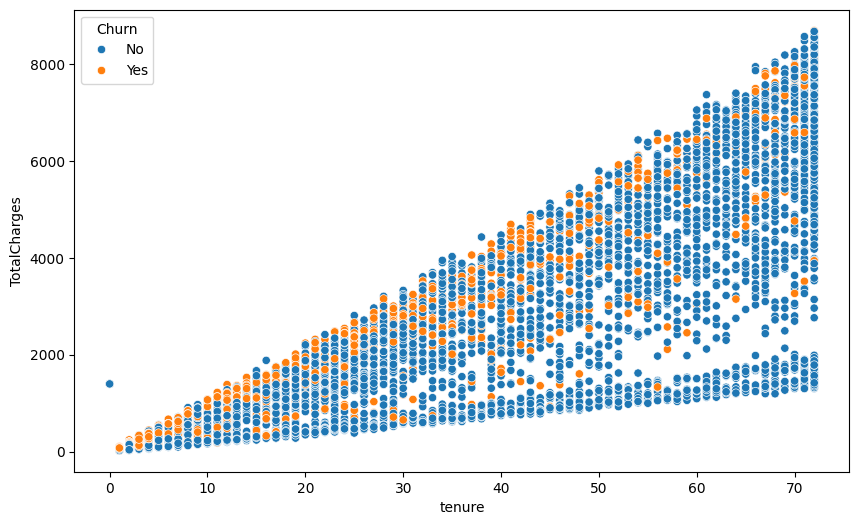

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='tenure',y='TotalCharges',hue='Churn',data=df)
plt.show()

1. the costomer who stay with thcompany for a longer period of time contribute more revanue over time.
2. those costomer stay longer with the company which shows there loyalty.

# 6. Contract + Gender + Churn

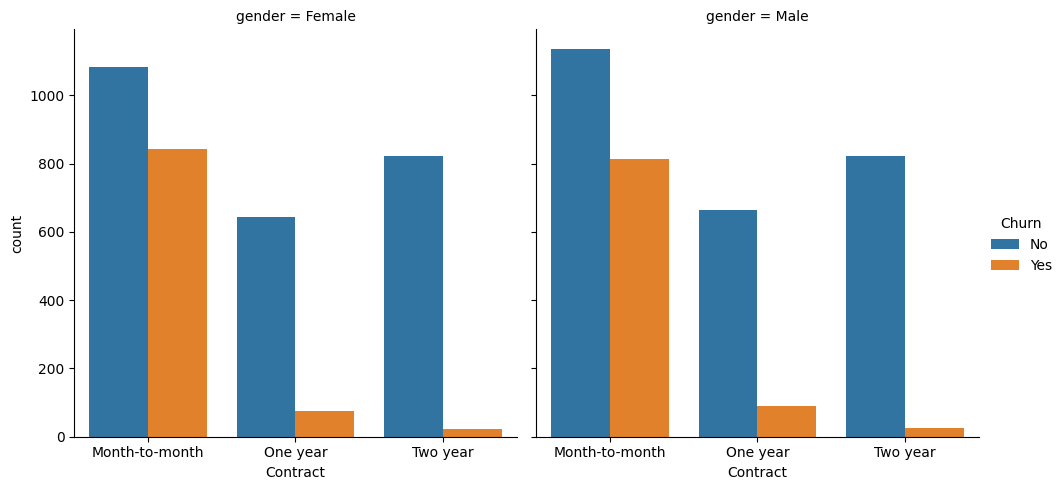

In [33]:
sns.catplot(x='Contract',hue='Churn',col='gender',kind='count',data=df)
plt.show()

Female customers with month-to-month contracts show higher churn.

# 7. MonthlyCharges Distribution by Contract and Churn

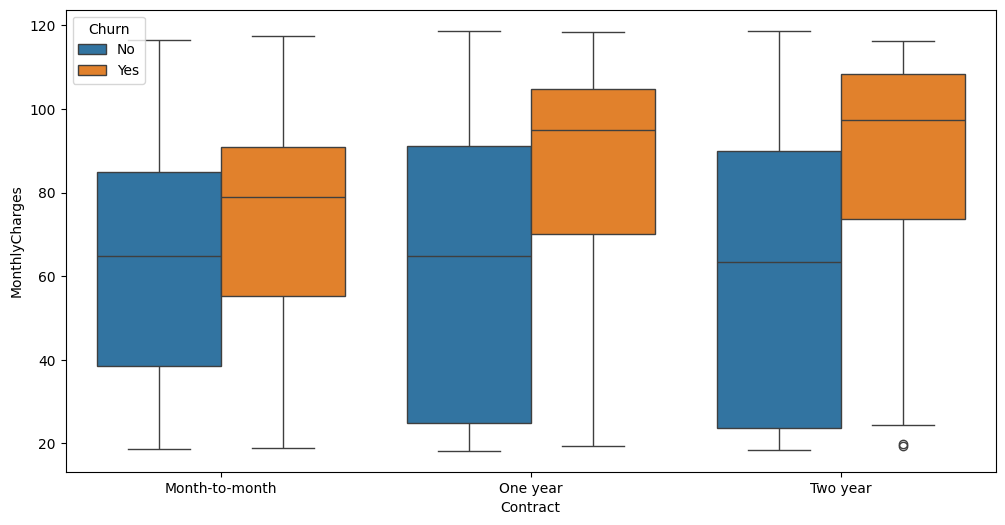

In [34]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Contract',
    y='MonthlyCharges',
    hue='Churn',
    data=df
)

plt.show()

High-paying month-to-month customers churn more.
Two-year contract customers churn least.

# 8. SeniorCitizen + Tenure + Churn

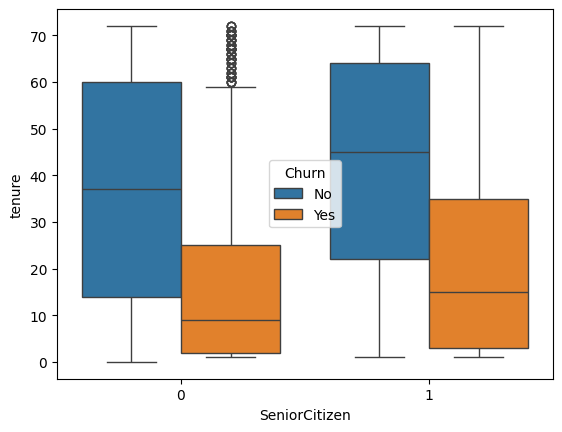

In [35]:
sns.boxplot(
    x='SeniorCitizen',
    y='tenure',
    hue='Churn',
    data=df
)
plt.show()

The boxplot shows that churned customers have significantly lower tenure than non-churned customers. This indicates that customers are more likely to leave during the early stages of their relationship with the company. Senior citizen status does not show a major impact on tenure distribution.

# 9. Contract + paymentmethod + Churn

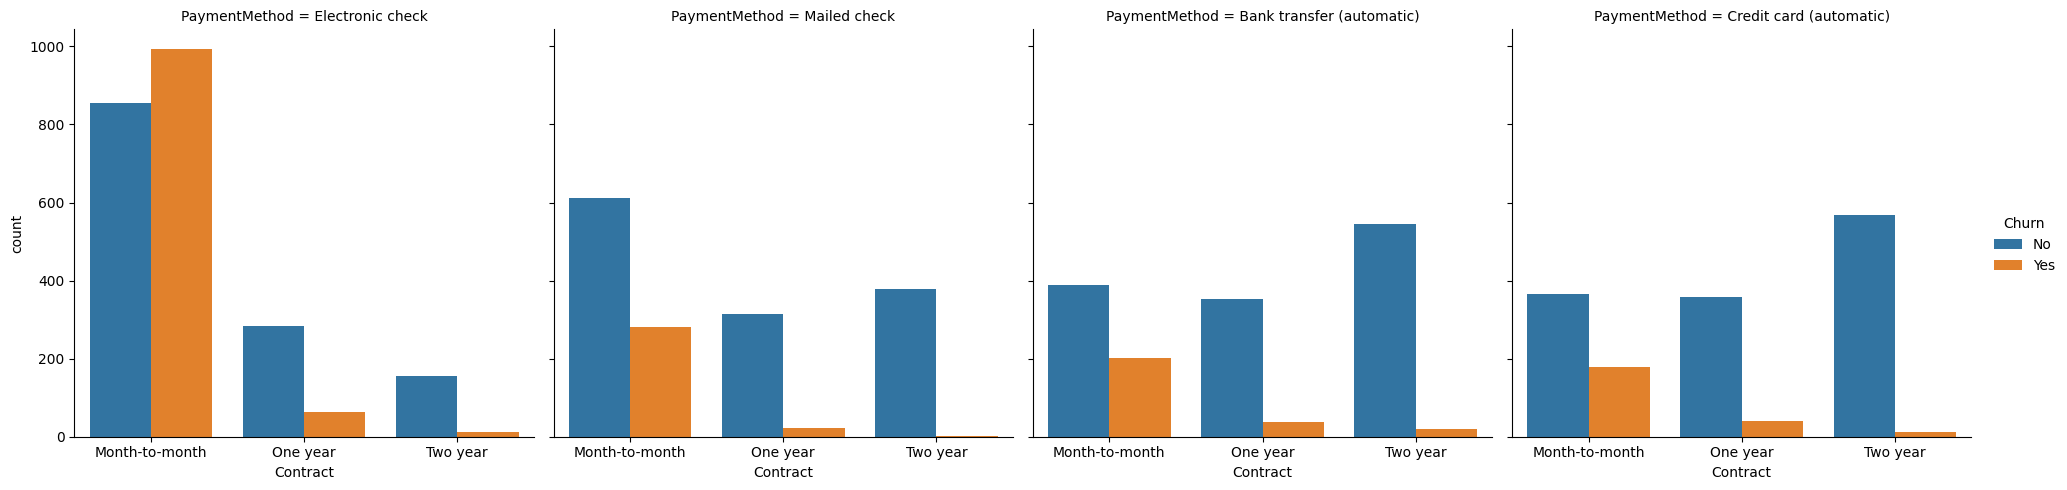

In [36]:
sns.catplot(x='Contract',hue='Churn',col='PaymentMethod',kind='count',data=df)
plt.show()

PaymentMethod = Electronic check, has more churned costomer in 'month-to-month' Contract category

## 10. SeniorCitizen + Contract + Churn

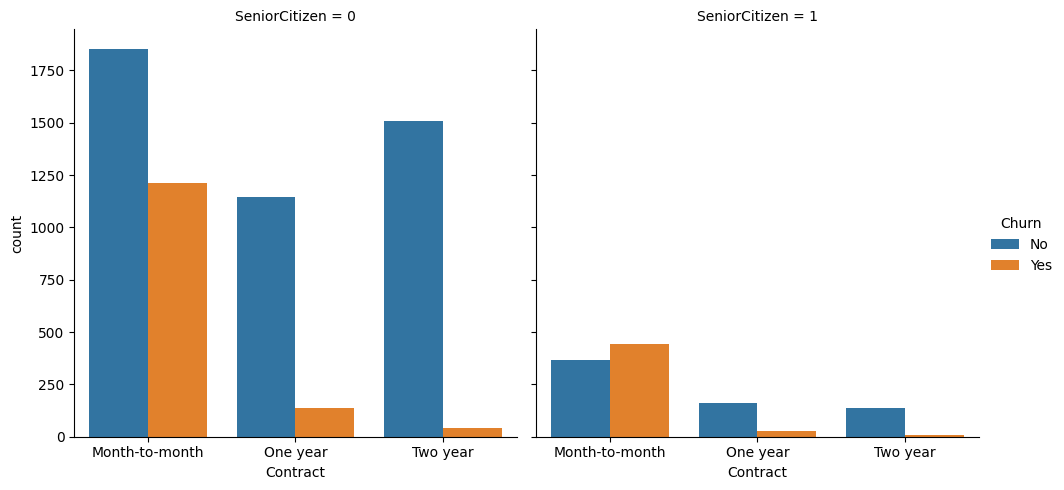

In [37]:
sns.catplot(x='Contract',hue='Churn',col='SeniorCitizen',kind='count',data=df)
plt.show()

 SeniorCitizen has more churned in 'month-to-month' Contract

# 11 Gender + Partner + Churn

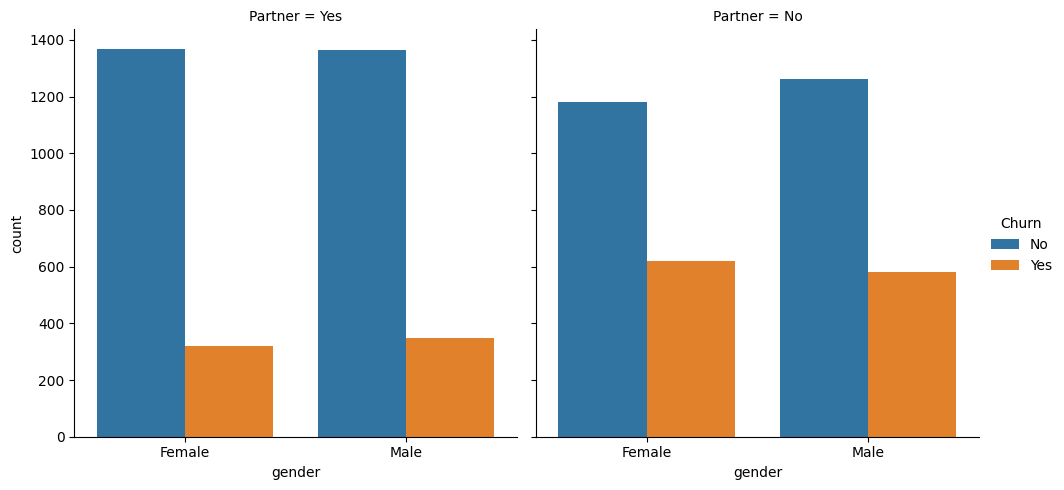

In [38]:
sns.catplot(x='gender',hue='Churn',col='Partner',kind='count',data=df)
plt.show()

There is high churn rate who has no partner in both the categories 'male', 'female'

# Step 5th Data Preprocessing

## 1. Remove Unnecessary Column

In [39]:
df.drop('customerID', axis=1, inplace=True)

## 2. Encode Target column

In [40]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [41]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

# 3. Features and Target

In [42]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)# stratify=y it balanced the dataset

# 4. Numerical and Categorical Columns

In [44]:
categorical_features = X.select_dtypes(include='object').columns

numerical_features = X.select_dtypes(exclude='object').columns

In [45]:
print(categorical_features)

print(numerical_features)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


# 5. Preprocessor

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_features),

        ('cat',OneHotEncoder(drop='first',handle_unknown='ignore'),categorical_features)])

# 6th. Final pipeline

In [47]:
pipeline = Pipeline([('preprocessing',preprocessor),
                     ('model',LogisticRegression(max_iter=1000, class_weight='balanced'))])

# Train

In [48]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Prediction

In [49]:
y_pred = pipeline.predict(X_test)

# Evaluation 

In [50]:
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.7381121362668559


In [51]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



# roc_auc_score

In [52]:
y_prob = pipeline.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)*100

84.16905629181845

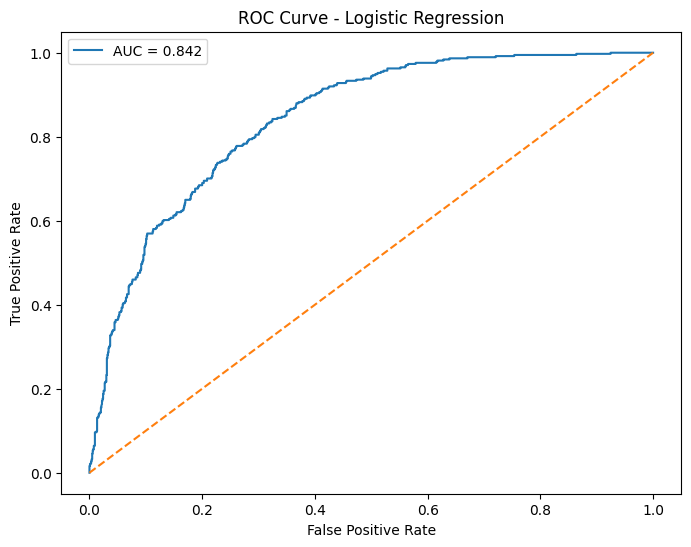

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = pipeline.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test,y_prob)

auc_score = roc_auc_score(y_test,y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,label=f'AUC = {auc_score:.3f}')

plt.plot([0,1],[0,1],linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve - Logistic Regression')

plt.legend()

plt.show()

# Confusion Matrix

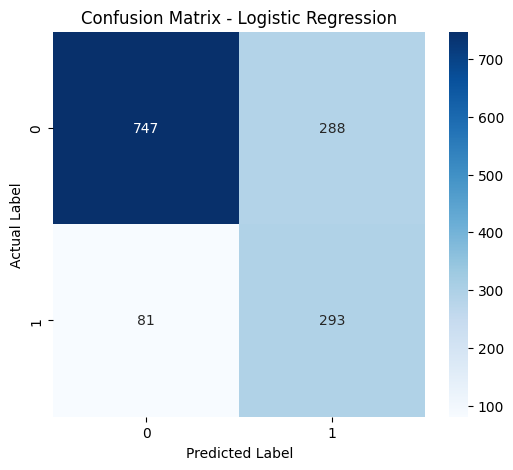

In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

# Cross Validation

In [55]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')

print("CV Scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())

CV Scores: [0.85818543 0.85855486 0.83307887 0.83773038 0.83918173]
Mean ROC-AUC: 0.8453462527595761


# Hyperparameter Tuning

In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'model__C': 100, 'model__solver': 'liblinear'}
Best ROC-AUC: 0.8455576979587056


In [57]:
best_model = grid.best_estimator_
best_model

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Save Best model

In [58]:
import joblib

joblib.dump(best_model, "customer_churn_pipeline.pkl")

['customer_churn_pipeline.pkl']

In [59]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


# 2. Random Forest Pipeline

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([

    (
        'preprocessing',
        preprocessor
    ),

    (
        'model2',
        RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42
        )
    )

])

In [61]:
rf_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessing', ...), ('model2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [62]:
rf_pred = rf_pipeline.predict(
    X_test
)

In [63]:
print("Accuracy:",accuracy_score(y_test, rf_pred))

Accuracy: 0.7885024840312278


In [64]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [65]:
rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

roc_auc_score(y_test, rf_prob)

0.8237541656978996

# 3.  from xgboost import XGBClassifier

In [100]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model3', XGBClassifier(
         n_estimators=500,
    learning_rate=0.01,
    scale_pos_weight=2.77,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
    ))
])


In [101]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model3', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [102]:
xgb_pipeline.score(X_train, y_train)*100, 

(75.94959176428824,)

In [103]:
xgb_pred = xgb_pipeline.predict(X_test)

In [104]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.82      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.74      0.76      1409



In [105]:
print("Accuracy:",accuracy_score(y_test, xgb_pred))

Accuracy: 0.7430801987224982


# Hyperparameter tuning for XG boost

In [99]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'model3__n_estimators': [200, 300, 500],
    'model3__max_depth': [3, 5, 7],
    'model3__learning_rate': [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'model3__learning_rate': 0.01, 'model3__max_depth': 3, 'model3__n_estimators': 500}
Best ROC-AUC: 0.8491367205457809


In [107]:
best_model = grid.best_estimator_

In [108]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.82      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.74      0.76      1409



In [110]:
# Final Model
best_model = grid.best_estimator_

In [111]:
# Model Save
import joblib

joblib.dump(best_model, "best_xgb_model.pkl")

['best_xgb_model.pkl']

# Feature Selection

In [71]:
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': pipeline.named_steps['model'].coef_[0]
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)


## Top Positive Features

In [72]:
print(coef_df.head(10))

                                Feature  Coefficient
10     cat__InternetService_Fiber optic     1.213162
3                     num__TotalCharges     0.477240
23             cat__StreamingMovies_Yes     0.417330
28  cat__PaymentMethod_Electronic check     0.405187
21                 cat__StreamingTV_Yes     0.392176
26            cat__PaperlessBilling_Yes     0.337270
9                cat__MultipleLines_Yes     0.322440
0                    num__SeniorCitizen     0.057315
29      cat__PaymentMethod_Mailed check     0.053329
17            cat__DeviceProtection_Yes     0.038686


## Top Negative Features

In [73]:
print(coef_df.tail(10))

                                    Feature  Coefficient
12  cat__OnlineSecurity_No internet service    -0.181665
8       cat__MultipleLines_No phone service    -0.183178
6                       cat__Dependents_Yes    -0.231859
19                     cat__TechSupport_Yes    -0.267915
13                  cat__OnlineSecurity_Yes    -0.336749
7                     cat__PhoneService_Yes    -0.344678
2                       num__MonthlyCharges    -0.534915
24                   cat__Contract_One year    -0.716996
1                               num__tenure    -1.147059
25                   cat__Contract_Two year    -1.413232


# Feature Importance Plot

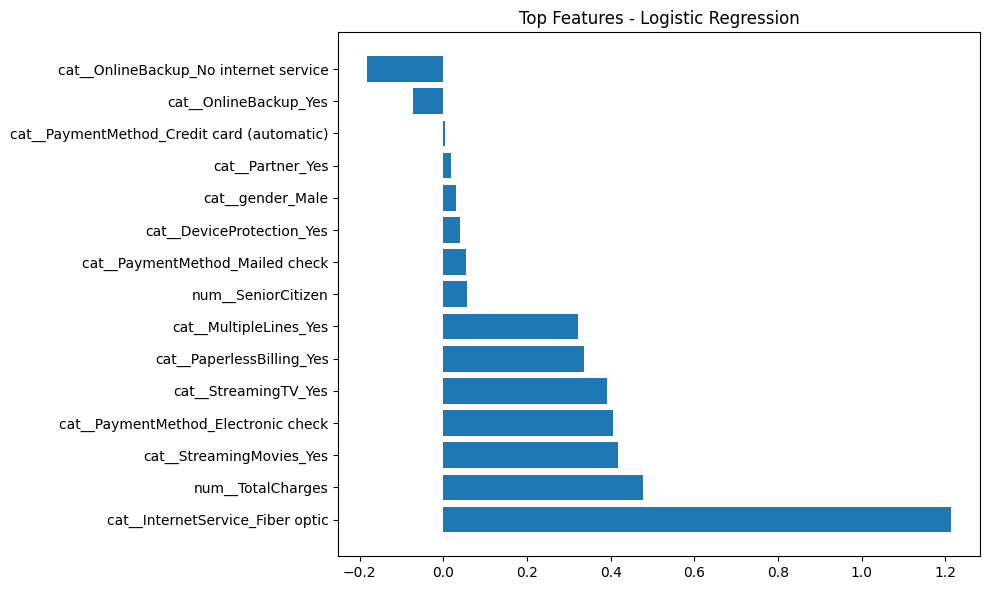

In [74]:
import matplotlib.pyplot as plt

top_features = coef_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.title("Top Features - Logistic Regression")
plt.tight_layout()
plt.show()

Feature Selection is the process of identifying the most important features that contribute to model predictions. I performed feature importance analysis after training the Logistic Regression model using coefficients. It helped me understand which features increased or decreased customer churn, improved model interpretability, and identified less useful features for future optimization.

# Absolute Importance

In [75]:
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])

top_features = coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
).head(10)

print(top_features)

                                Feature  Coefficient  Abs_Coefficient
25               cat__Contract_Two year    -1.413232         1.413232
10     cat__InternetService_Fiber optic     1.213162         1.213162
1                           num__tenure    -1.147059         1.147059
24               cat__Contract_One year    -0.716996         0.716996
2                   num__MonthlyCharges    -0.534915         0.534915
3                     num__TotalCharges     0.477240         0.477240
23             cat__StreamingMovies_Yes     0.417330         0.417330
28  cat__PaymentMethod_Electronic check     0.405187         0.405187
21                 cat__StreamingTV_Yes     0.392176         0.392176
7                 cat__PhoneService_Yes    -0.344678         0.344678


To identify the most influential features, I analyzed the Logistic Regression coefficients. Based on the absolute coefficient values, Contract_Two year, InternetService_Fiber optic, and tenure were the top three features affecting customer churn predictions. Positive coefficients increased churn probability, while negative coefficients reduced churn probability